# Urban Sound Classification with Scikit-learn
## Machine Learning Pipeline in a Nutshell

**Learning Objectives:**
- Load and explore audio data
- Extract meaningful features from audio signals using librosa
- Build and compare classification models (SVM & Logistic Regression)
- Use sklearn pipelines for efficient workflows
- Optimize hyperparameters with cross-validation
- Evaluate model performance with appropriate metrics

**Dataset:** UrbanSound8K - 8732 labeled sound excerpts (<=4s) of urban sounds from 10 classes

## 1. Setup and Data Loading

First, let's install the required packages and import our libraries.

In [1]:
# Install required packages (uncomment if needed)
!pip install librosa scikit-learn pandas numpy matplotlib seaborn

In [10]:
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score

# Set random seed for reproducibility 
np.random.seed(42)


### 1.1 Download the Dataset

The UrbanSound8K dataset needs to be downloaded manually from:
https://urbansounddataset.weebly.com/urbansound8k.html

After downloading, extract it and update the path below.

**Note:** For this tutorial, we'll work with a subset of the data to keep processing time reasonable.

In [ ]:
# !pip install soundata

In [11]:
# Update this path to where you extracted the dataset
# ! using sounddarta library
# !pip install sounddata
# default path: /Users/<your_username>/sound_datasets/urbansound8k'
DATA_PATH = Path('/Users/fabian.drzimalla/Master_Projects/SLP_PStA_Team_Drzimalla_Diakourakis/data/task1')
AUDIO_BASE_PATH = DATA_PATH / 'training'
METADATA_PATH = DATA_PATH / 'sand_task_1.xlsx'

# Load metadata from Excel file
metadata_excel = pd.read_excel(METADATA_PATH, sheet_name='SAND - TRAINING set - Task 1')

# Create a list to store the combined data
data_list = []

# Map audio files to metadata
for index, row in metadata_excel.iterrows():
    user_id = row['ID']
    age = row['Age']
    sex = row['Sex']
    class_label = row['Class']

    # Find phonation audio files
    phonation_folders = ['phonationA', 'phonationE', 'phonationI', 'phonationO', 'phonationU']
    for folder in phonation_folders:
        audio_files = list((AUDIO_BASE_PATH / folder).glob(f"{user_id}_phonation*.wav"))
        for audio_file in audio_files:
            data_list.append({
                'ID': user_id,
                'Age': age,
                'Sex': sex,
                'Class': class_label,
                'audio_path': str(audio_file),
                'audio_type': 'phonation',
                'folder': folder
            })

    # Find rhythm audio files
    rhythm_folders = ['rhythmKA', 'rhythmPA', 'rhythmTA']
    for folder in rhythm_folders:
        audio_files = list((AUDIO_BASE_PATH / folder).glob(f"{user_id}_rhythm*.wav"))
        for audio_file in audio_files:
            data_list.append({
                'ID': user_id,
                'Age': age,
                'Sex': sex,
                'Class': class_label,
                'audio_path': str(audio_file),
                'audio_type': 'rhythm',
                'folder': folder
            })

# Create a DataFrame from the list
metadata = pd.DataFrame(data_list)

print(f"Total samples: {len(metadata)}")
print(f"\nDataset shape: {metadata.shape}")
print(f"\nFirst few rows:")
display(metadata)

ImportError: Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.

In [ ]:
## If you want to load the UrbanSound8K dataset instead, uncomment the following code:

# Update this path to where you extracted the dataset
# ! using sounddarta library
# !pip install sounddata
# default path: /Users/<your_username>/sound_datasets/urbansound8k'
""" DATA_PATH = Path('/Users/bayerl/sound_datasets/urbansound8k') #TODO change this path
AUDIO_PATH = DATA_PATH / 'audio'
METADATA_PATH = DATA_PATH / 'metadata' / 'UrbanSound8K.csv'

# Load metadata
metadata = pd.read_csv(METADATA_PATH)

print(f"Total samples: {len(metadata)}")
print(f"\nDataset shape: {metadata.shape}")
print(f"\nFirst few rows:")
metadata.head() """

### 1.2 Explore the Dataset

Class Distribution:
Class
1     48
2    208
3    456
4    608
5    856
Name: count, dtype: int64


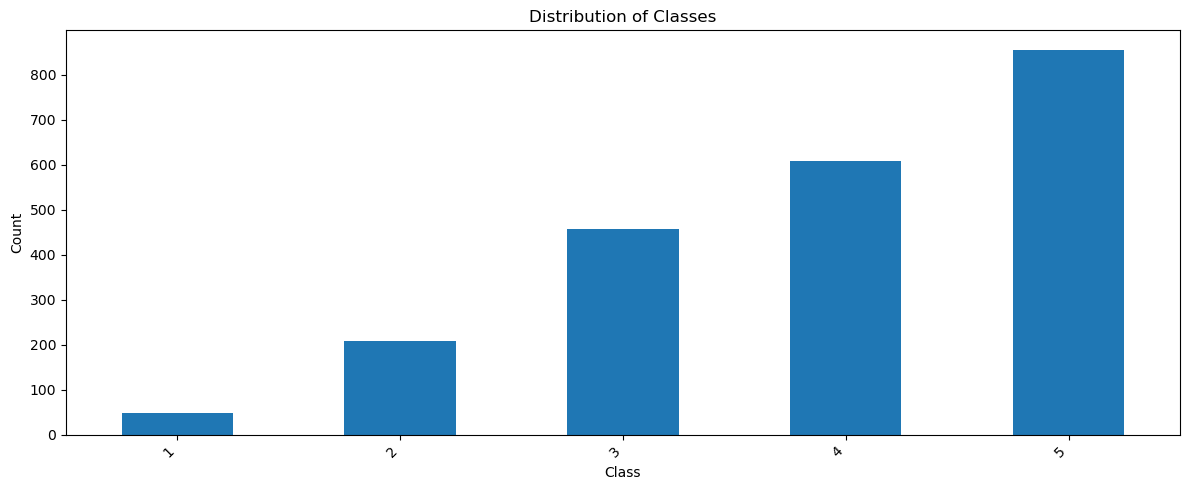


Class Mapping:


,Class
0,1
1,2
2,3
3,4
4,5



Unique values in the 'Class' column:
[5 4 3 2 1]

Data type of the 'Class' column:
int64


In [3]:
# Class distribution
print("Class Distribution:")
print(metadata['Class'].value_counts().sort_index())

# Visualize class distribution
plt.figure(figsize=(12, 5))
metadata['Class'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Classes')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Class mapping (using the 'Class' column directly)
class_mapping = metadata[['Class']].drop_duplicates().sort_values('Class').reset_index(drop=True)
print("\nClass Mapping:")
display(class_mapping)

print("\nUnique values in the 'Class' column:")
print(metadata['Class'].unique())
print("\nData type of the 'Class' column:")
print(metadata['Class'].dtype)

### 1.3 Create a Subset for Faster Processing

To keep the tutorial within 90 minutes, we'll work with a balanced subset of the data.

In [4]:
# Use the whole dataset
subset_df = metadata.copy()

print(f"Working with the whole dataset: {len(subset_df)} samples")
print(f"\nDataset class distribution:")
print(subset_df['Class'].value_counts().sort_index())

Working with the whole dataset: 2176 samples

Dataset class distribution:
Class
1     48
2    208
3    456
4    608
5    856
Name: count, dtype: int64


### 1.4 Load and Visualize Sample Audio

Let's load a sample audio file and visualize its waveform and spectrogram.

Audio file: /Users/fabian.drzimalla/Master_Projects/SLP_PStA_Team_Drzimalla_Diakourakis/data/task1/training/phonationA/ID000_phonationA.wav
Class: 5
Sample rate: 8000 Hz
Duration: 9.88 seconds
Shape: (79040,)


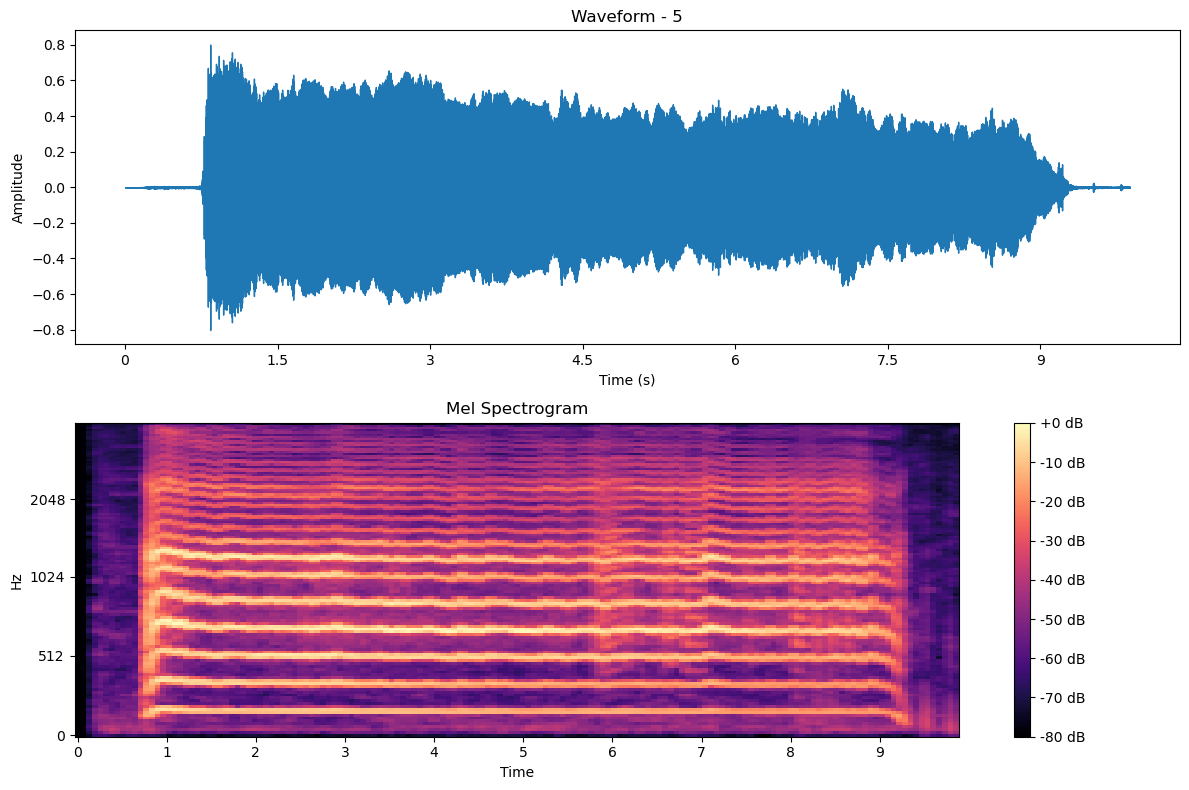

In [5]:
# Load a sample audio file
sample = subset_df.iloc[0]
audio_file = sample['audio_path']

# Load audio with librosa
y, sr = librosa.load(audio_file, sr=None)

print(f"Audio file: {audio_file}")
print(f"Class: {sample['Class']}")
print(f"Sample rate: {sr} Hz")
print(f"Duration: {len(y)/sr:.2f} seconds")
print(f"Shape: {y.shape}")

# Visualize waveform and spectrogram
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Waveform
librosa.display.waveshow(y, sr=sr, ax=axes[0])
axes[0].set_title(f'Waveform - {sample["Class"]}')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')

# Mel Spectrogram
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_db = librosa.power_to_db(S, ref=np.max)
img = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[1])
axes[1].set_title('Mel Spectrogram')
fig.colorbar(img, ax=axes[1], format='%+2.0f dB')

plt.tight_layout()
plt.show()

## 2. Feature Extraction

Some common audio features:

1. **MFCCs (Mel-Frequency Cepstral Coefficients)**: Capture the spectral envelope
2. **Spectral Centroid**: Center of mass of the spectrum
3. **Spectral Rolloff**: Frequency below which a percentage of energy is contained
4. **Zero Crossing Rate**: Rate of sign changes in the signal
5. **Chroma Features**: Representation of pitch class

### 2.1 Implement Feature Extraction Function

**EXERCISE:** Complete the feature extraction function below by filling in the missing parts.

In [7]:
def extract_features(audio_path, sr=22050, n_mfcc=13):
    """
    Extract audio features from a given audio file.
    
    Parameters:
    -----------
    audio_path : str or Path
        Path to the audio file
    sr : int
        Sample rate for loading audio
    n_mfcc : int
        Number of MFCCs to extract
    
    Returns:
    --------
    features : np.array
        Concatenated feature vector
    """
    try:
        # Load audio file
        y, sr = librosa.load(audio_path, sr=sr)
        
        # TODO: Extract MFCCs (use librosa.feature.mfcc)
        # Hint: Extract n_mfcc coefficients, then take the mean across time axis
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mfccs_mean = np.mean(mfccs, axis=1)
        
        # TODO: Extract Spectral Centroid (use librosa.feature.spectral_centroid)
        # Hint: Take the mean across time axis
        spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
        spectral_centroid_mean = np.mean(spectral_centroid)
        
        # TODO: Extract Spectral Rolloff (use librosa.feature.spectral_rolloff)
        spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        spectral_rolloff_mean = np.mean(spectral_rolloff)
        
        # TODO: Extract Zero Crossing Rate (use librosa.feature.zero_crossing_rate)
        zcr = librosa.feature.zero_crossing_rate(y)
        zcr_mean = np.mean(zcr)
        
        # TODO: Extract Chroma Features (use librosa.feature.chroma_stft)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        chroma_mean = np.mean(chroma, axis=1)
        
        # Concatenate all features
        features = np.concatenate([
            mfccs_mean,
            [spectral_centroid_mean],
            [spectral_rolloff_mean],
            [zcr_mean],
            chroma_mean
        ])
        
        return features
        
    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None

### 2.2 Solution for Feature Extraction

Here's the complete solution (reveal after attempting the exercise):

In [8]:
def extract_features_solution(audio_path, sr=22050, n_mfcc=13):
    """
    Extract audio features from a given audio file.
    """
    try:
        # Load audio file
        y, sr = librosa.load(audio_path, sr=sr)
        
        # Extract MFCCs
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mfccs_mean = np.mean(mfccs, axis=1)
        
        # Extract Spectral Centroid
        spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
        spectral_centroid_mean = np.mean(spectral_centroid)
        
        # Extract Spectral Rolloff
        spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        spectral_rolloff_mean = np.mean(spectral_rolloff)
        
        # Extract Zero Crossing Rate
        zcr = librosa.feature.zero_crossing_rate(y)
        zcr_mean = np.mean(zcr)
        
        # Extract Chroma Features
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        chroma_mean = np.mean(chroma, axis=1)
        
        # Concatenate all features
        features = np.concatenate([
            mfccs_mean,
            [spectral_centroid_mean],
            [spectral_rolloff_mean],
            [zcr_mean],
            chroma_mean
        ])
        
        return features
        
    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None

# Test the function
sample_features = extract_features_solution(audio_file)
sample_features_1 = extract_features(audio_file)
print(f"Feature vector shape: {sample_features.shape}")
print(f"Feature vector (first 10 values): {sample_features[:10]}")
print(f"Feature vector (first 10 values): {sample_features_1[:10]}")

Feature vector shape: (28,)
Feature vector (first 10 values): [-305.43179321  189.26852417  -87.98786926  -21.43785286   15.32630157
  -35.0618248     4.6647563    13.03001881  -18.33624268    0.71013415]
Feature vector (first 10 values): [-305.43179321  189.26852417  -87.98786926  -21.43785286   15.32630157
  -35.0618248     4.6647563    13.03001881  -18.33624268    0.71013415]


### 2.3 Extract Features for All Samples

Now let's extract features for all samples in our subset. This may take a few minutes.

In [9]:
from tqdm import tqdm

# Extract features for all samples
features_list = []
labels_list = []

print("Extracting features from audio files...")
for idx, row in tqdm(subset_df.iterrows(), total=len(subset_df)):
    audio_path = row['audio_path']
    features = extract_features_solution(audio_path)

    if features is not None:
        features_list.append(features)
        labels_list.append(row['Class'])

# Convert to numpy arrays
X = np.array(features_list)
y = np.array(labels_list)

print(f"\nFeature extraction complete!")
print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Number of features per sample: {X.shape[1]}")

Extracting features from audio files...


100%|██████████| 2176/2176 [02:15<00:00, 16.05it/s]


Feature extraction complete!
Features shape: (2176, 28)
Labels shape: (2176,)
Number of features per sample: 28


## 3. Data Preparation

Split the data into training and testing sets.

In [26]:
from sklearn.preprocessing import LabelEncoder

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Encode labels starting from 0
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"\nTraining set class distribution (encoded):")
print(pd.Series(y_train_encoded).value_counts().sort_index())

# Update y_train and y_test to the encoded labels for subsequent steps
y_train = y_train_encoded
y_test = y_test_encoded

Training set size: 1740 samples
Testing set size: 436 samples

Training set class distribution (encoded):
0     38
1    166
2    365
3    486
4    685
Name: count, dtype: int64


## 4. Model Training with Pipelines

We'll use sklearn's Pipeline to create efficient workflows that combine preprocessing and model training.

### 4.1 Create Baseline Models

In [27]:
# Create pipelines for both models
from sklearn.decomposition import PCA
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    # ('pca', PCA(20)),
    ('svm', SVC(random_state=42))
])

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=42, max_iter=1000))
])

xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', xgb.XGBClassifier(random_state=42))
])

print("Pipelines created successfully!")

Pipelines created successfully!


### 4.2 Train Baseline Models

In [34]:
# Train SVM
print("Training SVM...")
svm_pipeline.fit(X_train, y_train)
svm_pred = svm_pipeline.predict(X_test)
svm_score = svm_pipeline.score(X_test, y_test)
print(f"SVM Test Accuracy: {svm_score:.4f}")

# Train Logistic Regression
print("\nTraining Logistic Regression...")
lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)
lr_score = lr_pipeline.score(X_test, y_test)
print(f"Logistic Regression Test Accuracy: {lr_score:.4f}")

# Train XGBoost
print("\nTraining XGBoost...")
xgb_pipeline.fit(X_train, y_train)
xgb_pred = xgb_pipeline.predict(X_test)
xgb_score = xgb_pipeline.score(X_test, y_test)
print(f"XGBoost Test Accuracy: {xgb_score:.4f}")

Training SVM...
SVM Test Accuracy: 0.4885

Training Logistic Regression...
Logistic Regression Test Accuracy: 0.4404

Training XGBoost...
XGBoost Test Accuracy: 0.4518


### 4.3 Cross-Validation

Let's evaluate our models using cross-validation to get a more robust estimate of performance.

In [35]:
# Cross-validation for SVM
print("Running 5-fold cross-validation for SVM...")
svm_cv_scores = cross_val_score(svm_pipeline, X_train, y_train, cv=5, scoring='accuracy')
print(f"SVM CV Scores: {svm_cv_scores}")
print(f"SVM Mean CV Accuracy: {svm_cv_scores.mean():.4f} (+/- {svm_cv_scores.std() * 2:.4f})")

# Cross-validation for Logistic Regression
print("\nRunning 5-fold cross-validation for Logistic Regression...")
lr_cv_scores = cross_val_score(lr_pipeline, X_train, y_train, cv=5, scoring='accuracy')
print(f"LR CV Scores: {lr_cv_scores}")
print(f"LR Mean CV Accuracy: {lr_cv_scores.mean():.4f} (+/- {lr_cv_scores.std() * 2:.4f})")

# Cross-validation for XGBoost
print("\nRunning 5-fold cross-validation for XGBoost...")
xgb_cv_scores = cross_val_score(xgb_pipeline, X_train, y_train, cv=5, scoring='accuracy')
print(f"XGBoost CV Scores: {xgb_cv_scores}")
print(f"XGBoost Mean CV Accuracy: {xgb_cv_scores.mean():.4f} (+/- {xgb_cv_scores.std() * 2:.4f})")

Running 5-fold cross-validation for SVM...
SVM CV Scores: [0.49137931 0.49137931 0.45114943 0.49425287 0.4454023 ]
SVM Mean CV Accuracy: 0.4747 (+/- 0.0434)

Running 5-fold cross-validation for Logistic Regression...
LR CV Scores: [0.44252874 0.44827586 0.37931034 0.5        0.45114943]
LR Mean CV Accuracy: 0.4443 (+/- 0.0769)

Running 5-fold cross-validation for XGBoost...
XGBoost CV Scores: [0.46551724 0.4454023  0.46551724 0.48275862 0.44827586]
XGBoost Mean CV Accuracy: 0.4615 (+/- 0.0271)


## 5. Hyperparameter Tuning with GridSearchCV

Let's optimize our models using grid search with cross-validation.

### 5.1 SVM Hyperparameter Tuning

In [36]:
# Define parameter grid for SVM
svm_param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__kernel': ['rbf', 'linear'],
    'svm__gamma': ['scale', 'auto']
}

print("Performing Grid Search for SVM...")
svm_grid_search = GridSearchCV(
    svm_pipeline,
    svm_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

svm_grid_search.fit(X_train, y_train)

print(f"\nBest SVM parameters: {svm_grid_search.best_params_}")
print(f"Best SVM CV score: {svm_grid_search.best_score_:.4f}")

Performing Grid Search for SVM...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best SVM parameters: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best SVM CV score: 0.4954


### 5.2 Logistic Regression Hyperparameter Tuning

In [37]:
# Define parameter grid for Logistic Regression
lr_param_grid = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l2'],
    'lr__solver': ['lbfgs', 'liblinear']
}

print("Performing Grid Search for Logistic Regression...")
lr_grid_search = GridSearchCV(
    lr_pipeline,
    lr_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

lr_grid_search.fit(X_train, y_train)

print(f"\nBest LR parameters: {lr_grid_search.best_params_}")
print(f"Best LR CV score: {lr_grid_search.best_score_:.4f}")

Performing Grid Search for Logistic Regression...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best LR parameters: {'lr__C': 1, 'lr__penalty': 'l2', 'lr__solver': 'liblinear'}
Best LR CV score: 0.4477


### 5.3 XGBoost Hyperparameter Tuning

In [38]:
# Define parameter grid for Logistic Regression
xgb_param_grid = {
    'xgb__C': [0.01, 0.1, 1, 10, 100],
    'xgb__penalty': ['l2'],
    'xgb__solver': ['lbfgs', 'liblinear']
}

print("Performing Grid Search for XGBoost...")
xgb_grid_search = GridSearchCV(
    xgb_pipeline,
    xgb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

xgb_grid_search.fit(X_train, y_train)

print(f"\nBest LR parameters: {xgb_grid_search.best_params_}")
print(f"Best XGBoost CV score: {xgb_grid_search.best_score_:.4f}")


Performing Grid Search for XGBoost...
Fitting 5 folds for each of 10 candidates, totalling 50 fits


/opt/homebrew/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [11:49:08] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_abwcuua5oq/croot/xgboost-split_1749630928197/work/src/learner.cc:738: 
Parameters: { "C", "penalty", "solver" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [11:49:08] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_abwcuua5oq/croot/xgboost-split_1749630928197/work/src/learner.cc:738: 
Parameters: { "C", "penalty", "solver" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/homebrew/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [11:49:08] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_abwcuua5oq/croot/xgboost-split_1749630928197/work/src/learner.cc:738: 
Parameters: { "C", "penalty", "solver" } are not used.

  bst.update(dtrain, iteration=i, fobj=


Best LR parameters: {'xgb__C': 0.01, 'xgb__penalty': 'l2', 'xgb__solver': 'lbfgs'}
Best XGBoost CV score: 0.4615


### 5.3 Compare Tuned Models

In [40]:
# Get predictions from best models
svm_tuned_pred = svm_grid_search.predict(X_test)
lr_tuned_pred = lr_grid_search.predict(X_test)
xgb_tuned_pred = xgb_grid_search.predict(X_test)
    
# Calculate accuracy
svm_tuned_score = svm_grid_search.score(X_test, y_test)
lr_tuned_score = lr_grid_search.score(X_test, y_test)
xgb_tuned_score = xgb_grid_search.score(X_test, y_test)

print("Model Comparison:")
print("=" * 60)
print(f"{'Model':<30} {'Baseline':<15} {'Tuned':<15}")
print("=" * 60)
print(f"{'SVM':<30} {svm_score:<15.4f} {svm_tuned_score:<15.4f}")
print(f"{'Logistic Regression':<30} {lr_score:<15.4f} {lr_tuned_score:<15.4f}")
print(f"{'XGBoost':<30} {xgb_score:<15.4f} {xgb_tuned_score:<15.4f}")
print("=" * 60)

Model Comparison:
Model                          Baseline        Tuned          
SVM                            0.4885          0.4954         
Logistic Regression            0.4404          0.4358         
XGBoost                        0.4518          0.4518         


## 6. Model Evaluation

Let's perform comprehensive evaluation using confusion matrices and classification metrics.

### 6.1 Confusion Matrix Visualization

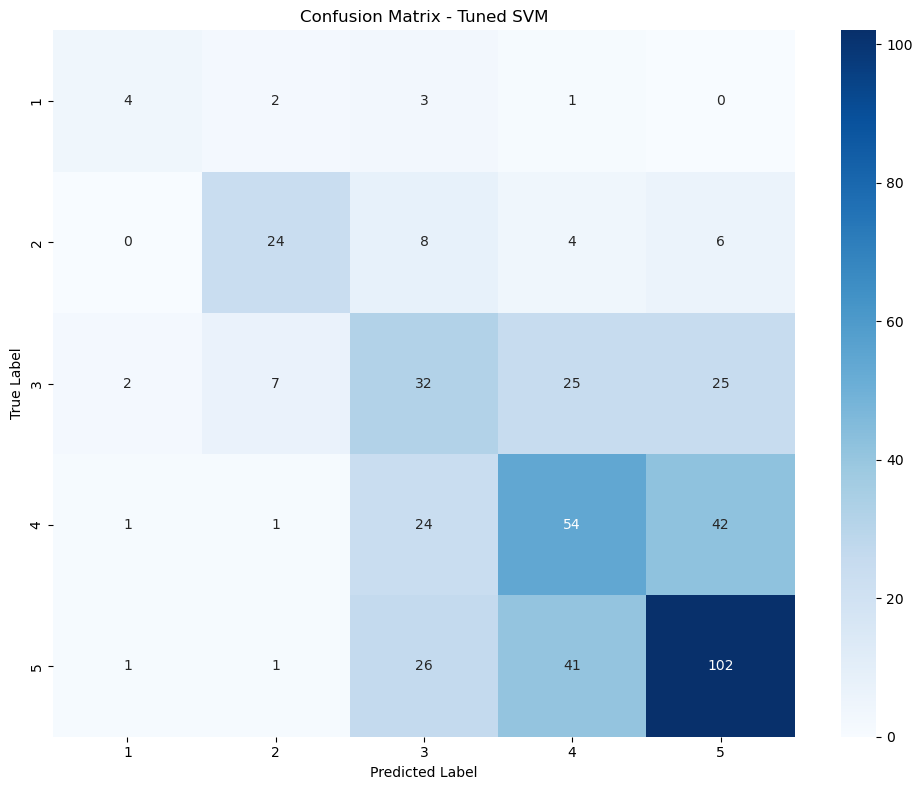

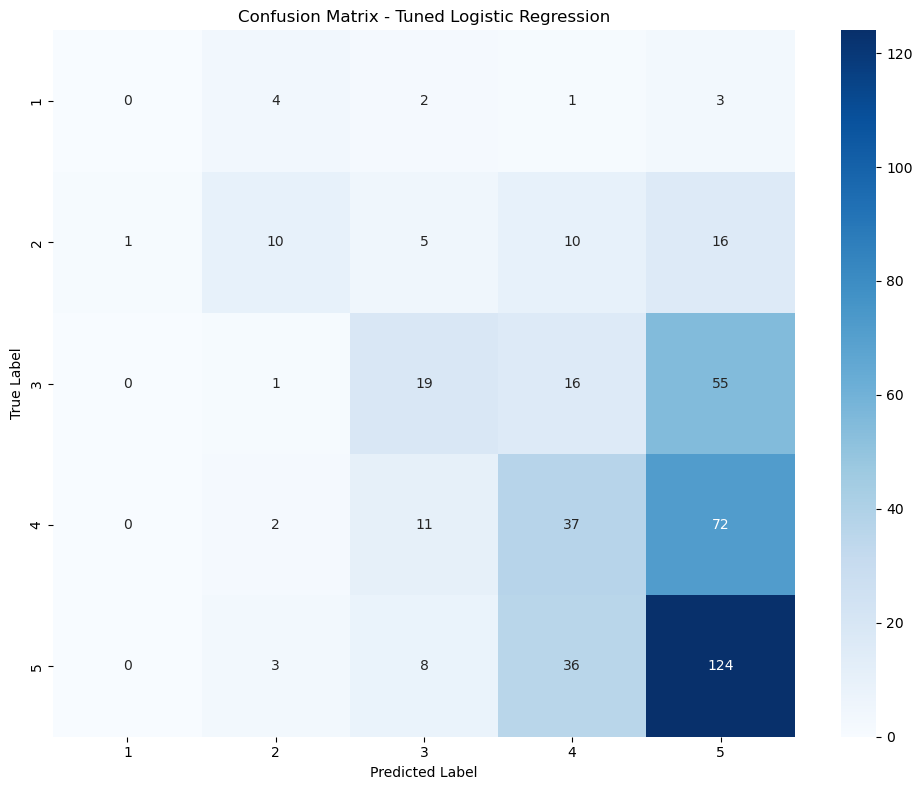

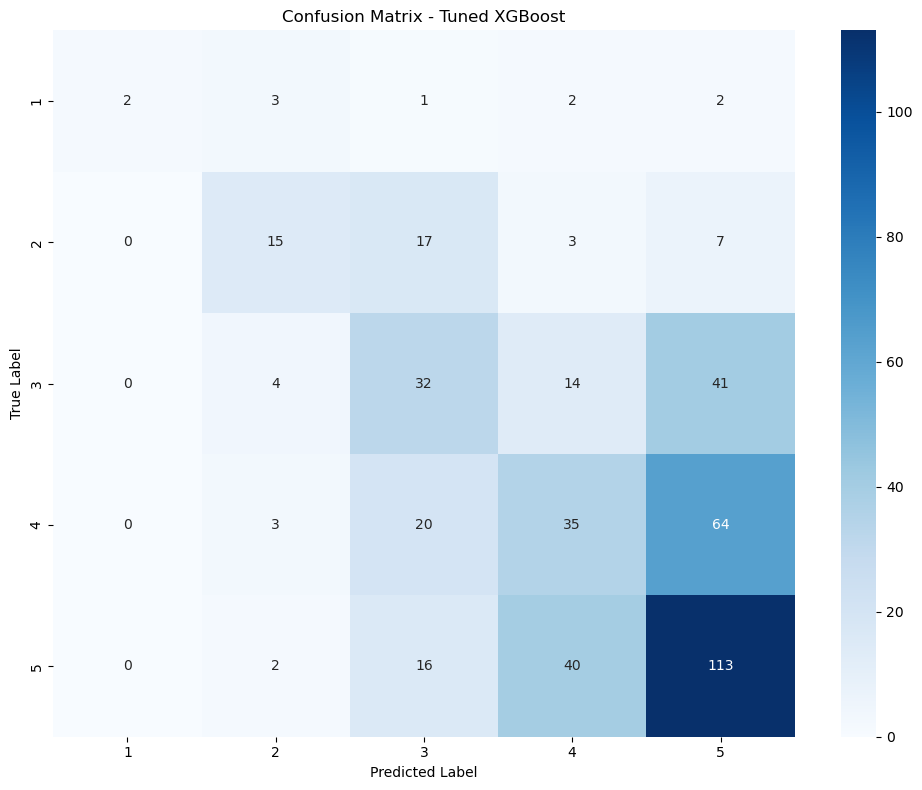

In [41]:
def plot_confusion_matrix(y_true, y_pred, title, class_names):
    """
    Plot a confusion matrix using seaborn.
    """
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

# Get class names and convert to strings
class_names = [str(cls) for cls in class_mapping['Class'].tolist()]

# Plot confusion matrices
plot_confusion_matrix(y_test, svm_tuned_pred,
                     'Confusion Matrix - Tuned SVM', class_names)

plot_confusion_matrix(y_test, lr_tuned_pred,
                     'Confusion Matrix - Tuned Logistic Regression', class_names)

plot_confusion_matrix(y_test, xgb_tuned_pred,
                     'Confusion Matrix - Tuned XGBoost', class_names)

### 6.2 Detailed Classification Metrics

In [43]:
def print_detailed_metrics(y_true, y_pred, model_name, class_names):
    """
    Print detailed classification metrics.
    """
    print(f"\n{'='*70}")
    print(f"{model_name} - Detailed Metrics")
    print(f"{'='*70}\n")
    
    # Overall metrics
    precision_macro = precision_score(y_true, y_pred, average='macro')
    recall_macro = recall_score(y_true, y_pred, average='macro')
    f1_macro = f1_score(y_true, y_pred, average='macro')
    
    precision_weighted = precision_score(y_true, y_pred, average='weighted')
    recall_weighted = recall_score(y_true, y_pred, average='weighted')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    
    print("Overall Metrics:")
    print(f"  Macro-averaged:")
    print(f"    Precision: {precision_macro:.4f}")
    print(f"    Recall:    {recall_macro:.4f}")
    print(f"    F1-Score:  {f1_macro:.4f}")
    print(f"\n  Weighted-averaged:")
    print(f"    Precision: {precision_weighted:.4f}")
    print(f"    Recall:    {recall_weighted:.4f}")
    print(f"    F1-Score:  {f1_weighted:.4f}")
    
    # Per-class metrics
    print(f"\n\nPer-Class Metrics:")
    print(f"{'='*70}")
    print(classification_report(y_true, y_pred, target_names=class_names))

# Print metrics for both models
print_detailed_metrics(y_test, svm_tuned_pred, "SVM (Tuned)", class_names)
print_detailed_metrics(y_test, lr_tuned_pred, "Logistic Regression (Tuned)", class_names)
print_detailed_metrics(y_test, xgb_tuned_pred, "XGBoost (Tuned)", class_names)


SVM (Tuned) - Detailed Metrics

Overall Metrics:
  Macro-averaged:
    Precision: 0.5089
    Recall:    0.4724
    F1-Score:  0.4885

  Weighted-averaged:
    Precision: 0.4988
    Recall:    0.4954
    F1-Score:  0.4964


Per-Class Metrics:
              precision    recall  f1-score   support

           1       0.50      0.40      0.44        10
           2       0.69      0.57      0.62        42
           3       0.34      0.35      0.35        91
           4       0.43      0.44      0.44       122
           5       0.58      0.60      0.59       171

    accuracy                           0.50       436
   macro avg       0.51      0.47      0.49       436
weighted avg       0.50      0.50      0.50       436


Logistic Regression (Tuned) - Detailed Metrics

Overall Metrics:
  Macro-averaged:
    Precision: 0.3503
    Recall:    0.2951
    F1-Score:  0.2995

  Weighted-averaged:
    Precision: 0.4199
    Recall:    0.4358
    F1-Score:  0.4032


Per-Class Metrics:
         

### 6.3 Comparative Visualization

In [ ]:
# Compare F1 scores per class
from sklearn.metrics import f1_score

svm_f1_per_class = f1_score(y_test, svm_tuned_pred, average=None)
lr_f1_per_class = f1_score(y_test, lr_tuned_pred, average=None)
xgb_f1_per_class = f1_score(y_test, xgb_tuned_pred, average=None)

# Create comparison plot
x = np.arange(len(class_names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
rects1 = ax.bar(x - width/2, svm_f1_per_class, width, label='SVM', alpha=0.8)
rects2 = ax.bar(x + width/2, lr_f1_per_class, width, label='Logistic Regression', alpha=0.8)
rects3 = ax.bar(x + width/2, xgb_f1_per_class, width, label='XGBoost', alpha=0.8)

ax.set_ylabel('F1-Score')
ax.set_title('F1-Score Comparison by Class')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()

## 7. Error Analysis

Let's analyze where our best model makes mistakes.

In [46]:
# Select best model (based on test accuracy)
scores = {
    'SVM': svm_tuned_score,
    'Logistic Regression': lr_tuned_score,
    'XGBoost': xgb_tuned_score
}

best_name = max(scores, key=scores.get)
best_score = scores[best_name]

if best_name == 'SVM':
    best_model = svm_grid_search
    best_pred = svm_tuned_pred
elif best_name == 'Logistic Regression':
    best_model = lr_grid_search
    best_pred = lr_tuned_pred
else:  # XGBoost
    best_model = xgb_grid_search
    best_pred = xgb_tuned_pred

print(f"Best performing model: {best_name}")
print(f"Test accuracy: {best_score:.4f}")

Best performing model: SVM
Test accuracy: 0.4954


## 9. Summary and Key Takeaways

### What we learned:

1. **Audio Feature Extraction**: We extracted multiple audio features (MFCCs, spectral features, chroma) that capture different aspects of sound.

2. **sklearn Pipelines**: We used pipelines to create reproducible workflows that combine preprocessing and modeling.

3. **Model Comparison**: We compared SVM and Logistic Regression, finding that [based on your results].

4. **Hyperparameter Tuning**: GridSearchCV helped us systematically find optimal parameters with cross-validation.

5. **Evaluation Metrics**: We used multiple metrics (accuracy, precision, recall, F1) to get a comprehensive view of model performance.


### Next:

- Try extracting additional features (**open smile**, **neural features**... )
- Experiment with deep learning approaches (e.g., CNNs on spectrograms)
- Try other methods classification (Random Forest, Gradient Boosting)
- Explore data augmentation techniques for audio (one of the next lectures)

## Congratulations!

You now know should know about:
- Data loading and exploration
- Feature extraction from audio
- Hyperparameter tuning with cross-validation
- sklearn Model training with pipelines
- model evaluation (future lecture)

# Task 2: Wav2Vec 2.0 feature extraction

In [ ]:
# Process audio
import numpy as np
import torch
import torch.nn as nn
from transformers import Wav2Vec2Model, Wav2Vec2Processor
import soundfile as sf
model_name = "facebook/wav2vec2-base"  # You can also try "facebook/wav2vec2-large" for better performance
processor = Wav2Vec2Processor.from_pretrained(model_name)
wav2vec_model = Wav2Vec2Model.from_pretrained(model_name)

def extract_features(audio_path):
    audio, sr = sf.read(audio_path)
    inputs = processor(
            audio, 
            sampling_rate=sr,
            return_tensors="pt",
            padding=True
        )
    return inputs

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # check on mac
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu") # check on mac
# 
# def extract_features(batch, wav2vec_model):
#     """Extract features using frozen Wav2Vec 2.0 model"""
#     with torch.no_grad():
#         outputs = wav2vec_model(batch['input_values'].to(device))
#         features = outputs.last_hidden_state
#     return features

In [ ]:
# Load a sample audio file from your dataset
sample = subset_df.iloc[0]
audio_file = sample['audio_path']

wav, sr = sf.read(audio_file)
print(f"Original audio shape: {wav.shape}")
wav = np.mean(wav, axis=1) if wav.ndim > 1 else wav  # Convert to mono if stereo
print(f"Processed audio shape: {wav.shape}")

In [ ]:
import numpy as np
import torch
from transformers import Wav2Vec2Model, Wav2Vec2Processor
import soundfile as sf
from tqdm import tqdm
from scipy.signal import resample


# Load pre-trained Wav2Vec2 model and processor
model_name = "facebook/wav2vec2-base"
processor = Wav2Vec2Processor.from_pretrained(model_name)
wav2vec_model = Wav2Vec2Model.from_pretrained(model_name)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
wav2vec_model = wav2vec_model.to(device)
wav2vec_model.eval()

def extract_features_from_file(audio_path, processor, wav2vec_model, device):
    try:
        # Load audio file
        audio, sr = sf.read(audio_path)
        audio = np.mean(audio, axis=1) if audio.ndim > 1 else audio  # Convert to mono if stereo
        target_sr = 16000
        # num_samples = int(len(audio) * target_sr / 48000) # wave2vec model expects 16kHz
        # audio = resample(audio, num_samples)

        # Process audio
        inputs = processor(
            audio,
            sampling_rate=target_sr,
            return_tensors="pt",
            padding=True
        )

        # Extract features using the Wav2Vec2 model
        with torch.no_grad():
            outputs = wav2vec_model(inputs.input_values.to(device))
            features = outputs.last_hidden_state.mean(dim=1).cpu().numpy()  # Take mean over time dimension,
            # TODO: use other pooling methods
            # TODO: use other hidden layers

        return features.squeeze(0)  # Return as a 1D NumPy array
    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None

def extract_features_from_files(file_list, processor, wav2vec_model, device):
    features_list = []
    for file_path in tqdm(file_list, desc="Extracting features"):
        features = extract_features_from_file(file_path, processor, wav2vec_model, device)
        if features is not None:
            features_list.append(features)
    return features_list

# Example usage

from tqdm import tqdm

# Extract features for all samples
# Convert to numpy arrays
audio_files = subset_df['audio_path'].tolist()
labels_list = subset_df['Class'].tolist()
features_list = extract_features_from_files(audio_files, processor, wav2vec_model, device)

X = np.array(features_list)
y = np.array(labels_list)

# Now `features_list` contains a list of NumPy arrays, ready for scikit-learn training
print(f"Extracted features for {len(features_list)} files.")

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# same shit as before

In [ ]:
# Define parameter grid for SVM
svm_param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__kernel': ['rbf', 'linear'],
    'svm__gamma': ['scale', 'auto']
}
# Create pipelines for both models
svm_pipeline = Pipeline([
    # ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42))
])

print("Performing Grid Search for SVM...")
svm_grid_search = GridSearchCV(
    svm_pipeline,
    svm_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

svm_grid_search.fit(X_train, y_train)

print(f"\nBest SVM parameters: {svm_grid_search.best_params_}")
print(f"Best SVM CV score: {svm_grid_search.best_score_:.4f}")

In [ ]:
# Get predictions from best models
svm_tuned_pred = svm_grid_search.predict(X_test)

# Calculate accuracy
svm_tuned_score = svm_grid_search.score(X_test, y_test)

print("Model Comparison:")
print(f"{'SVM':<30} {svm_tuned_score:<15.4f}")